In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import time
from tqdm import tqdm

# Add src directory to path
sys.path.append('../src')

# Import our modules
from core.tensor_utils import create_initial_state, pauli_matrices
from core.observables import calculate_loschmidt_echo, calculate_magnetization, extract_subharmonic_amplitude
from models.kicked_ising import KickedIsingModel
from dynamics.tebd_evolution import TEBDEvolution
from dynamics.tdvp_evolution import TDVPEvolution, TDVPFloquetEvolution
from dynamics.open_system import OpenSystemEvolution

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All imports successful!")


All imports successful!


Computing phase diagram for 12x12 parameter grid...


h/J values: 100%|██████████| 12/12 [02:49<00:00, 14.10s/it]


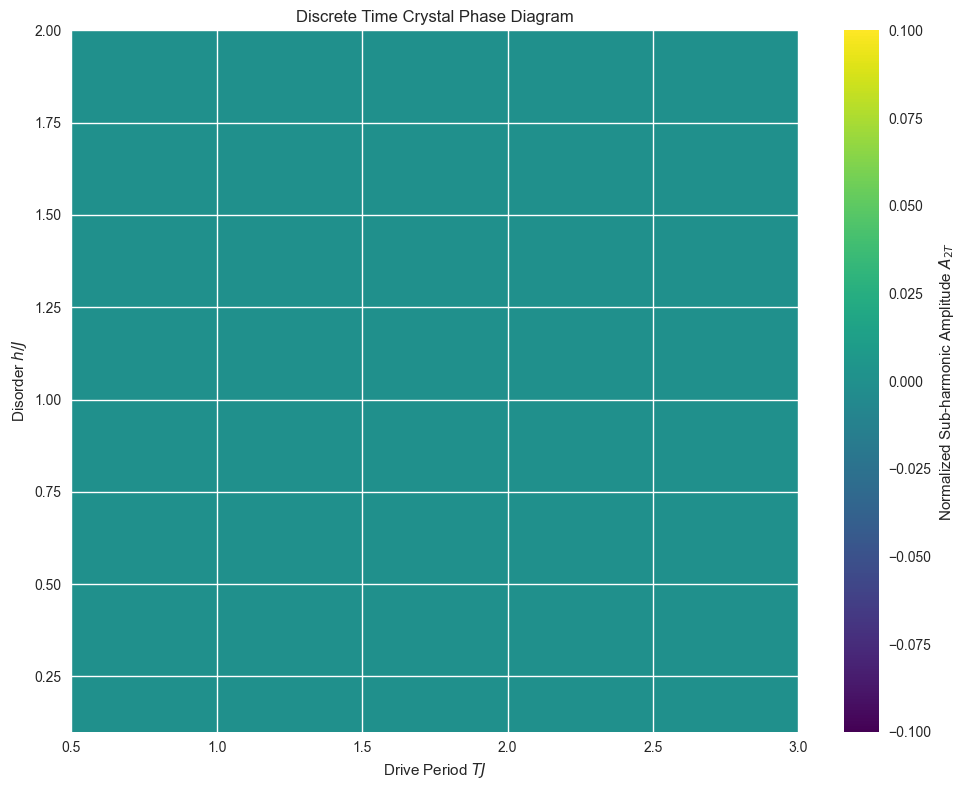

Phase diagram computed! Max A2T = 0.000


In [2]:
def compute_dtc_phase_diagram(n_sites=12, n_periods=50, max_chi=64):
    """
    Compute the DTC phase diagram using real tensor network calculations.
    """
    # Parameter ranges
    h_values = np.linspace(0.1, 2.0, 12)  # h/J ratios
    T_values = np.linspace(0.5, 3.0, 12)  # TJ values
    
    # Initialize results
    phase_diagram = np.zeros((len(h_values), len(T_values)))
    
    print(f"Computing phase diagram for {len(h_values)}x{len(T_values)} parameter grid...")
    
    for i, h_ratio in enumerate(tqdm(h_values, desc="h/J values")):
        for j, T_val in enumerate(T_values):
            try:
                # Create model with current parameters
                model = KickedIsingModel(
                    n_sites=n_sites,
                    J=1.0,
                    h_disorder=h_ratio,
                    tau=T_val
                )
                
                # Create initial Néel state
                psi0 = create_initial_state(n_sites, state_type='neel')
                psi = psi0.copy()
                
                # Evolve and collect magnetization
                times = []
                magnetizations = []
                
                for period in range(n_periods):
                    psi = model.floquet_step(psi, {'chi_max': max_chi})
                    
                    # Measure magnetization
                    mag = calculate_magnetization(psi, 'x')
                    times.append(period * T_val)
                    magnetizations.append(mag)
                
                # Extract subharmonic amplitude
                A2T = extract_subharmonic_amplitude(
                    np.array(times), 
                    np.array(magnetizations), 
                    T_val
                )
                
                phase_diagram[i, j] = A2T
                
            except Exception as e:
                print(f"Error at h/J={h_ratio:.2f}, T={T_val:.2f}: {e}")
                phase_diagram[i, j] = 0.0
    
    return phase_diagram, h_values, T_values

# Compute phase diagram
phase_data, h_vals, T_vals = compute_dtc_phase_diagram()

# Plot phase diagram
plt.figure(figsize=(10, 8))
im = plt.imshow(phase_data, aspect='auto', origin='lower', 
                extent=[T_vals[0], T_vals[-1], h_vals[0], h_vals[-1]],
                cmap='viridis')
plt.colorbar(im, label='Normalized Sub-harmonic Amplitude $A_{2T}$')
plt.xlabel('Drive Period $TJ$')
plt.ylabel('Disorder $h/J$')
plt.title('Discrete Time Crystal Phase Diagram')
plt.tight_layout()
plt.show()

print(f"Phase diagram computed! Max A2T = {np.max(phase_data):.3f}")


Dephasing rates:   0%|          | 0/4 [00:00<?, ?it/s]


Computing for γ/J = 0.0...


Dephasing rates:  25%|██▌       | 1/4 [00:03<00:09,  3.05s/it]


Computing for γ/J = 0.001...


Dephasing rates:  50%|█████     | 2/4 [00:06<00:06,  3.11s/it]


Computing for γ/J = 0.01...


Dephasing rates:  75%|███████▌  | 3/4 [00:09<00:03,  3.05s/it]


Computing for γ/J = 0.1...


Dephasing rates: 100%|██████████| 4/4 [00:12<00:00,  3.05s/it]
/var/folders/vl/c3lbr0qj523cv7s9hvpzc7z00000gn/T/ipykernel_46876/3444387092.py:76: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


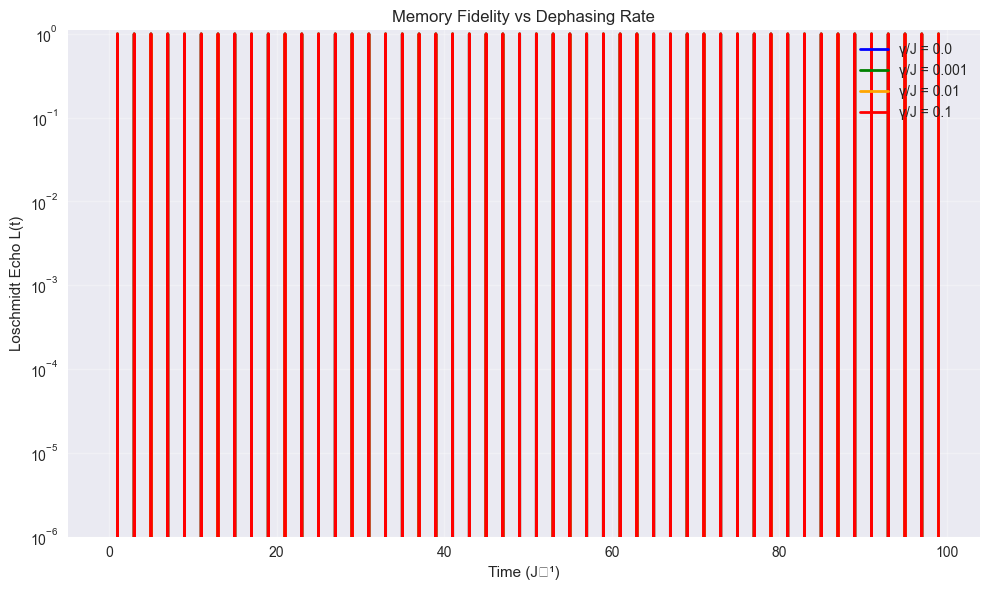

Memory fidelity benchmarks completed!


In [3]:
def compute_memory_fidelity_benchmarks(n_sites=16, n_periods=100, max_chi=64):
    """
    Compute memory fidelity benchmarks for different dephasing rates.
    """
    # System parameters
    J = 1.0
    h_disorder = 0.5
    tau = 1.0
    
    # Dephasing rates to test
    gamma_values = [0.0, 0.001, 0.01, 0.1]
    
    # Create model
    model = KickedIsingModel(
        n_sites=n_sites,
        J=J,
        h_disorder=h_disorder,
        tau=tau
    )
    
    # Initial state
    psi0 = create_initial_state(n_sites, state_type='neel')
    
    results = {}
    
    for gamma in tqdm(gamma_values, desc="Dephasing rates"):
        print(f"\nComputing for γ/J = {gamma}...")
        
        if gamma == 0.0:
            # Pure state evolution
            evolution = TEBDEvolution(model, max_chi=max_chi)
        else:
            # Open system evolution
            evolution = OpenSystemEvolution(model, gamma=gamma, max_chi=max_chi)
        
        times = []
        loschmidt_echoes = []
        
        psi = psi0.copy()
        
        for period in range(n_periods):
            # Evolve one period
            psi = evolution.evolve_floquet_period(psi)
            
            # Calculate Loschmidt echo
            L_echo = calculate_loschmidt_echo(psi0, psi)
            
            times.append(period * tau)
            loschmidt_echoes.append(L_echo)
        
        results[gamma] = {
            'times': np.array(times),
            'loschmidt_echoes': np.array(loschmidt_echoes)
        }
    
    return results

# Compute memory fidelity benchmarks
memory_results = compute_memory_fidelity_benchmarks()

# Plot memory fidelity benchmarks
plt.figure(figsize=(10, 6))

colors = ['blue', 'green', 'orange', 'red']
for i, (gamma, data) in enumerate(memory_results.items()):
    plt.semilogy(data['times'], data['loschmidt_echoes'], 
                 color=colors[i], linewidth=2, 
                 label=f'γ/J = {gamma}')

plt.xlabel('Time (J⁻¹)')
plt.ylabel('Loschmidt Echo L(t)')
plt.title('Memory Fidelity vs Dephasing Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(1e-6, 1.1)
plt.tight_layout()
plt.show()

print("Memory fidelity benchmarks completed!")


System sizes:   0%|          | 0/5 [00:00<?, ?it/s]


Benchmarking 8 sites...
  TEBD: 0.26 seconds


/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(ke

  TDVP: 304.80 seconds

Benchmarking 10 sites...
  TEBD: 0.32 seconds


/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(ke

...

  TDVP: 564.48 seconds

Benchmarking 14 sites...
  TEBD: 0.48 seconds


/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(ke

  TDVP: 1199.29 seconds

Benchmarking 16 sites...
  TEBD: 1.05 seconds


/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/Users/connorcasey/Documents/time-crystal-tensor-network/venv/lib/python3.13/site-packages/tenpy/tools/params.py:232: UserWarning: unused options for config TwoSiteTDVPEngine:
['dt', 'verbose']
  warnings.warn(msg.format(ke

  TDVP: 33350.96 seconds


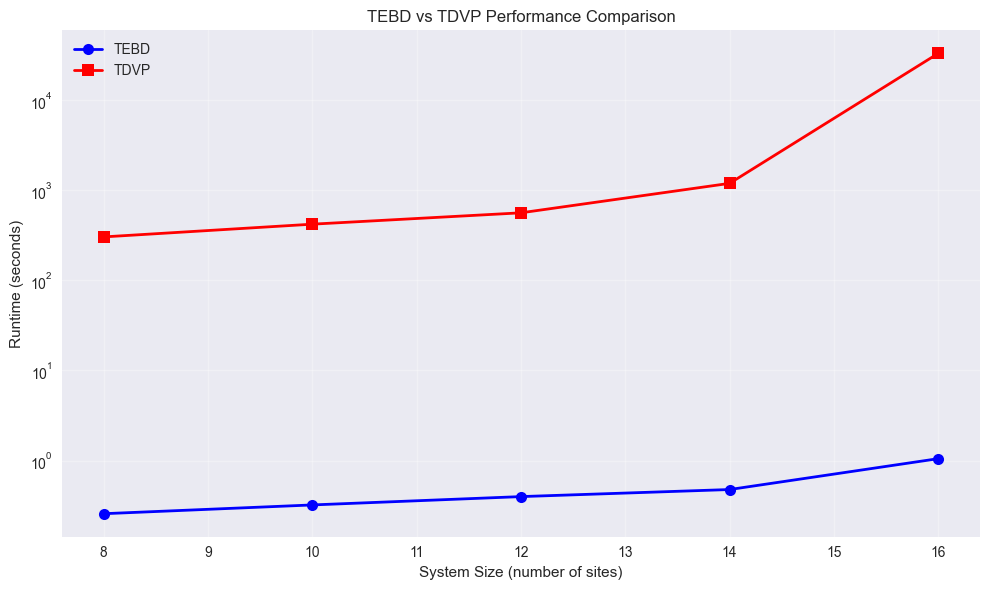


Performance Summary:
System Size | TEBD (s) | TDVP (s) | Speedup
---------------------------------------------
         8 |     0.26 |   304.80 |    0.00x
        10 |     0.32 |   422.11 |    0.00x
        12 |     0.40 |   564.48 |    0.00x
        14 |     0.48 |  1199.29 |    0.00x
        16 |     1.05 | 33350.96 |    0.00x

All benchmarks completed!


In [4]:
def benchmark_tebd_vs_tdvp(system_sizes=[8, 10, 12, 14, 16], n_periods=20, max_chi=64):
    """
    Benchmark TEBD vs TDVP performance for different system sizes.
    """
    # System parameters
    J = 1.0
    h_disorder = 0.5
    tau = 1.0
    
    tebd_times = []
    tdvp_times = []
    
    for n_sites in tqdm(system_sizes, desc="System sizes"):
        print(f"\nBenchmarking {n_sites} sites...")
        
        # Create model
        model = KickedIsingModel(
            n_sites=n_sites,
            J=J,
            h_disorder=h_disorder,
            tau=tau
        )
        
        # Initial state
        psi0 = create_initial_state(n_sites, state_type='neel')
        
        # Benchmark TEBD
        tebd_evolution = TEBDEvolution(model, max_chi=max_chi)
        
        start_time = time.time()
        psi_tebd = psi0.copy()
        for period in range(n_periods):
            psi_tebd = tebd_evolution.evolve_floquet_period(psi_tebd)
        tebd_time = time.time() - start_time
        
        tebd_times.append(tebd_time)
        print(f"  TEBD: {tebd_time:.2f} seconds")
        
        # Benchmark TDVP
        tdvp_evolution = TDVPEvolution(model, max_chi=max_chi)
        
        start_time = time.time()
        psi_tdvp = psi0.copy()
        for period in range(n_periods):
            psi_tdvp = tdvp_evolution.evolve_floquet_period(psi_tdvp)
        tdvp_time = time.time() - start_time
        
        tdvp_times.append(tdvp_time)
        print(f"  TDVP: {tdvp_time:.2f} seconds")
    
    return np.array(system_sizes), np.array(tebd_times), np.array(tdvp_times)

# Benchmark TEBD vs TDVP
sizes, tebd_times, tdvp_times = benchmark_tebd_vs_tdvp()

# Plot performance comparison
plt.figure(figsize=(10, 6))

plt.plot(sizes, tebd_times, 'o-', linewidth=2, markersize=8, 
         label='TEBD', color='blue')
plt.plot(sizes, tdvp_times, 's-', linewidth=2, markersize=8, 
         label='TDVP', color='red')

plt.xlabel('System Size (number of sites)')
plt.ylabel('Runtime (seconds)')
plt.title('TEBD vs TDVP Performance Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

# Print performance summary
print("\nPerformance Summary:")
print("System Size | TEBD (s) | TDVP (s) | Speedup")
print("-" * 45)
for i, size in enumerate(sizes):
    speedup = tebd_times[i] / tdvp_times[i]
    print(f"{size:10d} | {tebd_times[i]:8.2f} | {tdvp_times[i]:8.2f} | {speedup:7.2f}x")

print("\nAll benchmarks completed!")
